# DATASCI 530 – Assignment 2

Ye Yuan

09/16/2026

This assignment analyzes the Formula 1 dataset. It merges 'results.csv', 'races.csv', and 'constructors.csv' and compares the points won by different constructors. Results show that Ferrari, Mercedes, and Red Bull/McLaren are the most successful constructors since 1980s.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Read data

In [88]:
results = pd.read_csv("data_raw/results.csv")
races = pd.read_csv("data_raw/races.csv")
constructors = pd.read_csv("data_raw/constructors.csv")

## Merge data

In [ ]:
# merge results with information about the races

data_races_to_results = pd.merge(results,
                                 races,
                                 on = "raceId",
                                 how = "left")

# merge results and races with information about constructors

data = pd.merge(data_races_to_results,
                constructors.rename(columns={"name": "constructor_name"}),
                on = "constructorId",
                how = "left")



## Question a)

In [90]:
# points earned by constructors 1981-2020
# generate a new ranking variable based on total points

summary_constructor_81_20 = (data.query("1981 <= year <= 2020")
                             .groupby(["constructorId", "constructor_name"], as_index = False)
                             .agg(points_sum = ("points", "sum"),
                                  points_mean = ("points", "mean"))
                             .sort_values(by = "points_sum", ascending = False)
                             .assign(
                                ranking = lambda x: (
                                    x["points_sum"]
                                    .rank(method = "min", ascending = False)
                                    .astype(int)))
                                    .reset_index(drop = True))

# tidy the table and show the first 20 rows

summary_constructor_81_20.head(20)\
    .drop(columns="constructorId")\
        .rename(columns = {
    "constructor_name": "Constructor",
    "points_sum": "Total points won",
    "points_mean": "Average points won",
    "ranking": "Ranking",
}).style.format({
    "Total points won": "{:,.1f}",
    "Average points won": "{:,.2f}"
}).hide(axis = "index").set_caption("Points won by top 20 constructors (1981-2020)")

Constructor,Total points won,Average points won,Ranking
Ferrari,"7,374.0",5.35,1
Mercedes,"5,685.0",13.22,2
McLaren,"5,229.5",3.78,3
Red Bull,"5,043.5",8.30,4
Williams,"3,355.0",2.42,5
Renault,"1,710.0",2.41,6
Force India,"1,098.0",2.59,7
Benetton,861.5,1.66,8
Lotus F1,706.0,4.58,9
Sauber,557.0,0.71,10


In [91]:
avg_points_81_20 = summary_constructor_81_20["points_sum"].mean()

avg_points_81_20

np.float64(532.2388059701492)

The three constructors that have earned the most points during 1981 and 2020 were Ferrari (7374 points in total), Mercedes (5685 points in total), and McLaren (5229.5 points in total). The average points across constructors between 1981 and 2020 are ~ 532. So the total points of the three best constructors are larger than the average.

## Question b)

In [92]:
# points earned by constructors 2001-2020
# generate a new ranking variable based on total points

summary_constructor_01_20 = (data.query("2001 <= year <= 2020")
                                 .groupby(["constructorId", "constructor_name"], as_index = False)
                                 .agg(points_sum = ("points", "sum"),
                                 points_mean = ("points", "mean"))
                                 .sort_values(by = "points_sum", ascending = False)
                                 .assign(
                                    ranking = lambda x: (
                                        x["points_sum"]
                                        .rank(method="min", ascending=False)
                                        .astype(int)))
                                        .reset_index(drop=True))

# tidy the table and show the first 20 rows

summary_constructor_01_20.head(20)\
    .drop(columns = "constructorId")\
        .rename(columns = {
    "constructor_name": "Constructor",
    "points_sum": "Total points won",
    "points_mean": "Average points won",
    "ranking": "Ranking",
}).style.format({
    "Total points won": "{:,.1f}",
    "Average points won": "{:,.2f}"
}).hide(axis = "index").set_caption("Points won by top 20 constructors (2001-2020)")

Constructor,Total points won,Average points won,Ranking
Ferrari,"5,862.0",7.88,1
Mercedes,"5,685.0",13.22,2
Red Bull,"5,043.5",8.30,3
McLaren,"3,284.0",4.41,4
Williams,"1,535.5",2.06,5
Renault,"1,465.0",2.63,6
Force India,"1,098.0",2.59,7
Lotus F1,706.0,4.58,8
Toro Rosso,500.0,0.93,9
Sauber,467.0,0.88,10


In [93]:
avg_points_01_20 = summary_constructor_01_20["points_sum"].mean()

avg_points_01_20

np.float64(786.0142857142857)

The top three constructors between 2001 and 2020 are Ferrari (5,862), Mercedes (5,685), and Red Bull (5043.5). The average points across constructors between 2001 and 2020 are ~ 786. So the total points of the three best constructors are larger than the average.

## Question c)

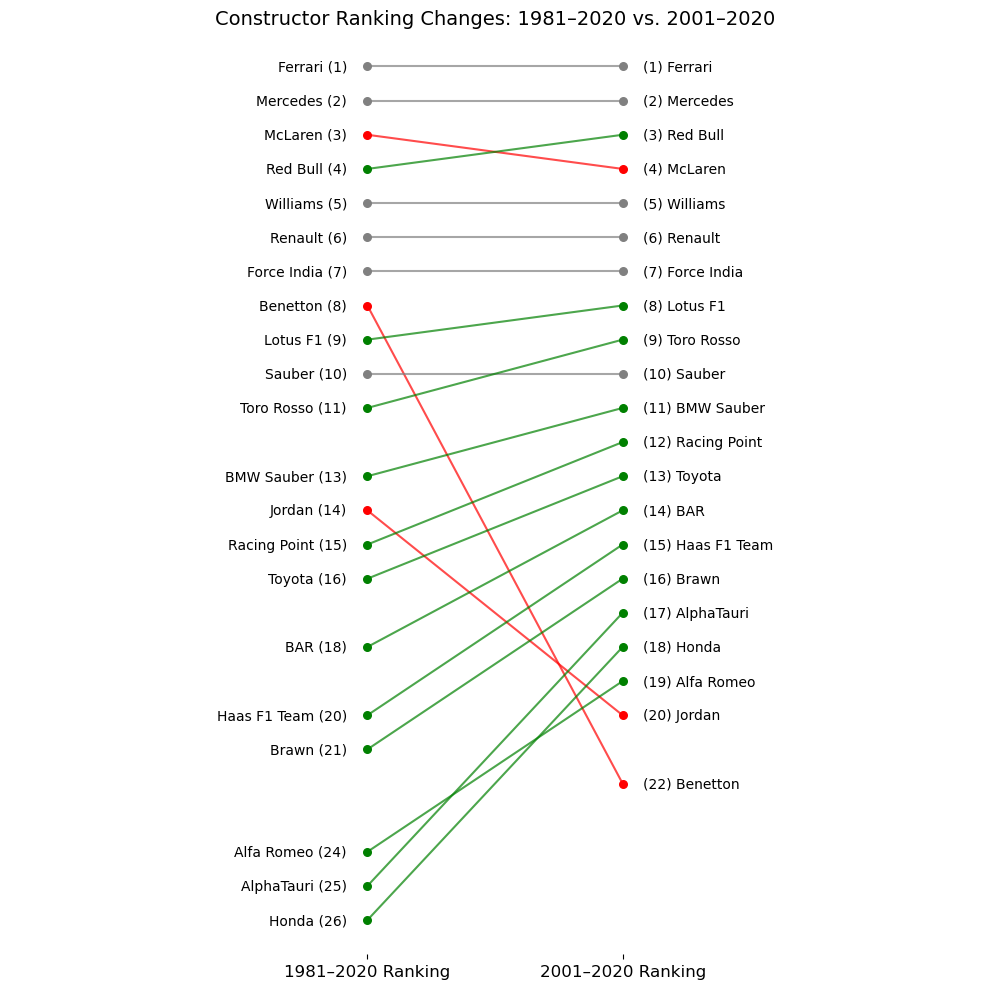

In [94]:
# illustrate the change of rankings

ranking_change = pd.merge(
    summary_constructor_81_20[
        ["constructorId", "constructor_name", "ranking"]
    ].rename(columns={"ranking": "ranking_81_20"}),

    summary_constructor_01_20[
        ["constructorId", "constructor_name", "ranking"]
    ].rename(columns={"ranking": "ranking_01_20"}),

    on=["constructorId", "constructor_name"],
    how="left")

# keep constructors in both periods
# and that have rankings in top 20
plot_data = ranking_change[
    (ranking_change["ranking_81_20"] <= 20) |
    (ranking_change["ranking_01_20"] <= 20)
].dropna(subset=["ranking_81_20", "ranking_01_20"]).copy()

plot_data["ranking_81_20"] = plot_data["ranking_81_20"].astype(int)
plot_data["ranking_01_20"] = plot_data["ranking_01_20"].astype(int)

# plot ranking change
fig, ax = plt.subplots(figsize=(10, 10))

for _, row in plot_data.iterrows():

    old_rank = row["ranking_81_20"]
    new_rank = row["ranking_01_20"]
    name = row["constructor_name"]

    # denote the direction of change
    if new_rank < old_rank:
        color = "green"
    elif new_rank > old_rank:
        color = "red"
    else:
        color = "gray"

    # plot lines
    ax.plot(
        [0, 0.5],
        [old_rank, new_rank],
        color = color,
        alpha = 0.7,
        linewidth = 1.5
    )

    # plot ends
    ax.scatter(
        [0, 0.5],
        [old_rank, new_rank],
        color=color,
        s = 30
    )

    # left label
    ax.text(
        -0.04,
        old_rank,
        f"{name} ({old_rank})",
        ha="right",
        va="center",
        fontsize = 10
    )

    # right label
    ax.text(
        0.54,
        new_rank,
        f"({new_rank}) {name}",
        ha="left",
        va="center",
        fontsize = 10
    )

# x-axis
ax.set_xticks([0, 0.5])
ax.set_xticklabels(
    ["1981–2020 Ranking", "2001–2020 Ranking"],
    fontsize = 12
)

# showing the ranking #1 at top
max_rank = max(
    plot_data["ranking_81_20"].max(),
    plot_data["ranking_01_20"].max()
)

ax.set_ylim(max_rank + 1, 0)
ax.set_xlim(-0.7, 1.2)

ax.set_yticks([])
ax.set_title(
    "Constructor Ranking Changes: 1981–2020 vs. 2001–2020",
    fontsize = 14
)

# remove boxes
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

From the plot, most of the constructors in top 10 remain stable in ranking, except for Benetton, who dropped dramatically from 8 to 22 (which turns out that Benetton hasn't attend the F1 after 2001). Another observation is that McLaren and Red Bull exchanged their rankings. Out of top 10, most of the constructors made some improvements, possibly due to some constructors didn't attend the F1 during 2001-2020.

## Question d)

In [95]:
# drivers Ferrari have between 1981-2020

data.query("constructor_name == 'Ferrari' & 1981 <= year <= 2020")["driverId"].nunique()


25

## Question e)

In [96]:
# the best year of ferrari (1981-2020)

summary_ferrari_81_20 = (data.query("constructor_name == 'Ferrari' & 1981 <= year <= 2020")
                             .groupby("year", as_index = False)
                             .agg(points_sum = ("points", "sum"))
                             .sort_values(by = "points_sum", ascending = False))

summary_ferrari_81_20.head(5).rename(columns = {
    "year": "Year",
    "points_sum": "Total points won"
}).style.format({
    "Year": "{:.0f}",
    "Total points won": "{:,.1f}"
}).hide(axis = "index").set_caption("Top 5 Yearly points won by Ferrari (1981-2020)")

Year,Total points won
2018,571.0
2017,522.0
2019,504.0
2015,428.0
2012,400.0


The best year for Ferrari between 1981 and 2020 is 2018.

## New insight question

What's the yearly trend of McLaren and Red Bull's performance from 1981 to 2020?

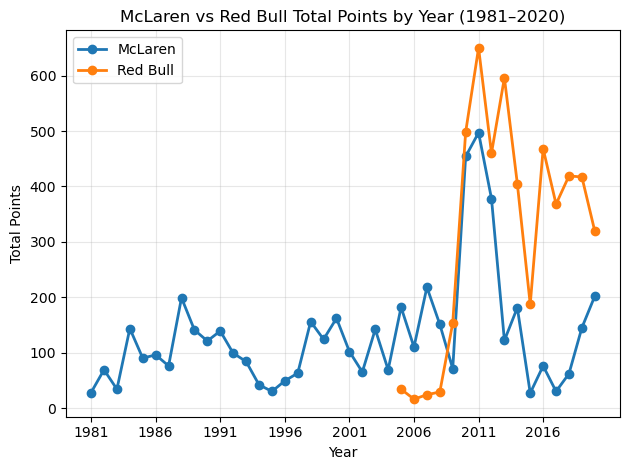

In [97]:
summary_ML_RB_81_20 = (data.query("(constructor_name == 'McLaren' | \
    constructor_name == 'Red Bull') & \
            1981 <= year <= 2020")
            .groupby(["year", "constructor_name"], as_index = False)
            .agg(points_sum = ("points", "sum")))

for team in ["McLaren", "Red Bull"]:
    df = summary_ML_RB_81_20.query("constructor_name == @team")
    plt.plot(df["year"],
             df["points_sum"],
             marker = "o",
             linewidth = 2,
             label = team)

plt.title("McLaren vs Red Bull Total Points by Year (1981–2020)")
plt.xlabel("Year")
plt.ylabel("Total Points")
plt.xticks(range(1981, 2021, 5))
plt.grid(alpha = 0.3)
plt.legend()

plt.tight_layout()
plt.show()

The figure shows that McLaren maintained a long history of competitiveness from 1981 onward. In contrast, Red Bull entered F1 in 2005 but experienced a dramatic rise beginning around 2009, quickly evolving from a new entrant into one of the dominant teams. Since 2010, Red Bull has consistently outperformed McLaren in terms of total points. Although both teams experienced declines after reaching their peaks around 2011, their performances became more stable after 2016, with McLaren showing a modest recovery beginning in 2018.